In [41]:
# constructive_phi_barycentric.py
from __future__ import annotations
from typing import Optional, Literal, Sequence
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander
import scipy as sp
import jax.scipy as jsp

# ----- FP64
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

In [42]:
# =========================
# Chebyshev tools (Lobatto)
# =========================
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    """Nodes x_j = cos(pi * j / K), j=0..K (Chebyshev-Lobatto)."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)

def cheb_vandermonde(x: np.ndarray, K: int) -> np.ndarray:
    """
    Returns A with shape (len(x), K+1) where A[j, k] = T_k(x_j).
    """
    return jnp.array(chebvander(np.asarray(x), K))

def cheb_monomial_coeffs(K: int) -> jnp.ndarray:
    """
    C[k,p] s.t. T_k(x) = sum_{p=0}^k C[k,p] x^p.
    """
    C = np.zeros((K + 1, K + 1), dtype=np.float64)
    C[0,0] = 1.0
    if K >= 1: C[1,1] = 1.0
    for k in range(1, K):
        Tk, Tkm1 = C[k], C[k-1]
        two_x_Tk = np.zeros(K + 1, dtype=np.float64)
        two_x_Tk[1:] = 2.0 * Tk[:-1]
        C[k+1] = two_x_Tk - Tkm1
    return jnp.asarray(C, dtype=DTYPE)

In [43]:
# ==============================================
# Barycentric (2nd form) at Chebyshev–Lobatto
# ==============================================
def lobatto_bary_weights(K: int) -> jnp.ndarray:
    """Weights w_j = (-1)^j * c_j with c_0=c_K=1/2 else 1."""
    j = jnp.arange(K + 1, dtype=DTYPE)
    w = jnp.ones((K + 1,), dtype=DTYPE)
    w = w.at[0].set(0.5).at[-1].set(0.5)
    w = w * ((-1.0) ** j)
    return w


def barycentric_eval_lobatto(x_nodes: jnp.ndarray,
                             y_nodes: jnp.ndarray,
                             x_eval: jnp.ndarray) -> jnp.ndarray:
    """Second barycentric formula at Lobatto nodes."""
    K = x_nodes.shape[0] - 1
    w = lobatto_bary_weights(K)  # (K+1,)
    x_eval = jnp.asarray(x_eval, dtype=DTYPE)
    x_nodes = x_nodes.astype(DTYPE); y_nodes = y_nodes.astype(DTYPE)

    def one_point(x):
        diffs = x - x_nodes
        idx = jnp.argmin(jnp.abs(diffs))
        return jnp.where(jnp.isclose(diffs[idx], 0.0),
                         y_nodes[idx],
                         (jnp.sum(w * y_nodes / diffs) / jnp.sum(w / diffs)))
    return jax.vmap(one_point)(x_eval)

In [44]:
# ======================================
# Get Chebyshev T_k coefficients via SVD
# ======================================
def cheb_coeffs_from_lobatto(y_nodes: jnp.ndarray, K: int) -> jnp.ndarray:
    """
    For interpolation degree K at Lobatto nodes x_j = cos(pi j / K), j=0..K, solve:
       sum_{k=0}^K c_k T_k(x_j) = y_j
    using SVD (square but robust).
    """
    x_nodes = cheb_lobatto_nodes(K)
    A = cheb_vandermonde(x_nodes, K)     # (K+1, K+1)
    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    print(f"SVD cond(A) ~ {float(S[0]/S[-1]):.3e}")
    Sinv = 1.0 / S
    c = (Vh.T * Sinv) @ (U.T @ y_nodes.astype(DTYPE))
    return c  # c_k (k=0..K)


In [45]:
def calibrate_M_to_chebyshev(
    K: int,
    act: Literal["tanh","exp","sin"],
    b: DTYPE,
    h: DTYPE,
    r_grid: jnp.ndarray,          # shape (R,)
    oversample: int = 12,          # N ≈ oversample * (K+1)
    rcond: float | None = None,   # SVD cutoff
) -> jnp.ndarray:
    """
    Returns M with shape (K+1, R) such that Phi(x) @ M^T ≈ T(x) on [-1,1],
    where Phi_j,i = φ(b + h r_i x_j). This bypasses divided differences.
    """
    # 1) calibration grid (Chebyshev 2nd-kind; avoid only endpoints)
    N = max(4*(K+1), oversample*(K+1))
    j = jnp.arange(N, dtype=DTYPE)
    x_cal = jnp.cos((j + 0.5) * jnp.pi / N)                      # (N,)

    # 2) build design Phi and targets T
    if act == "tanh":
        Phi = jnp.tanh(x_cal[:, None] * (r_grid[None, :] * h) + b)
    elif act == "exp":
        Phi = jnp.exp (x_cal[:, None] * (r_grid[None, :] * h) + b)
    elif act == "sin":
        Phi = jnp.sin (x_cal[:, None] * (r_grid[None, :] * h) + b)
    else:
        raise ValueError

    T = cheb_vandermonde(np.asarray(x_cal), K)                   # (N, K+1)

    # 3) column scaling + SVD pseudoinverse (stable)
    col = jnp.maximum(jnp.linalg.norm(Phi, axis=0), DTYPE(1e-300))  # (R,)
    A = Phi / col                                                   # (N,R)

    U, S, Vh = jnp.linalg.svd(A, full_matrices=False)
    if rcond is None:
        rcond = 0.0 #float(jnp.finfo(DTYPE).eps)  # conservative
        print(f"Using default rcond={rcond:.1e}")
    Sinv = jnp.where(S > S[0]*rcond, 1.0/S, 0.0)

    # M solves A @ (Diag(col) @ M^T) ≈ T  ⇒  M^T ≈ Diag(1/col) @ A^+ @ T
    M_T = (Vh.T * Sinv) @ (U.T @ T)                                 # (R, K+1)
    M_T = M_T / col[:, None]
    M = M_T.T                                                       # (K+1, R)

    # 4) optional row scaling (as you already do)
    row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
    return M / row_scale, row_scale.squeeze(-1)                     # scale rows later


In [46]:
# =======================================
# Activation + derivative helpers
# =======================================
def analytic_bias_for_tanh(choice="pi") -> tuple[float, float]:
    """Pick b with tanh(b)=t transcendental (helps avoid accidental cancellations)."""
    if choice == "pi":
        t = jnp.asarray(1.0 / jnp.pi, dtype=DTYPE)
    else:
        t = jnp.asarray(jnp.exp(-1.0), dtype=DTYPE)
    b = jnp.arctanh(t)
    return float(b), float(t)

def tanh_derivatives_at_b_poly(K: int, t: float) -> jnp.ndarray:
    """Return [tanh(b), tanh'(b), ..., tanh^{(K)}(b)], via P_{n+1}=(1-y^2)P'_n."""
    t = jnp.asarray(t, dtype=DTYPE)
    L = K + 2
    coeff = jnp.zeros(L, dtype=DTYPE).at[1].set(1.0)  # P0(y)=y
    derivs = jnp.zeros(K + 1, dtype=DTYPE).at[0].set(t)

    def poly_derivative(c):
        idx = jnp.arange(1, L, dtype=DTYPE)
        return jnp.zeros_like(c).at[:-1].set(idx * c[1:])

    def mul_by_1_minus_y2(c):
        return jnp.zeros_like(c).at[:].add(c).at[2:].add(-c[:-2])

    def poly_eval(c, t_):
        return jax.lax.fori_loop(0, L, lambda j, acc: acc * t_ + c[L-1-j], DTYPE(0.0))

    def step(n, carry):
        c, d = carry
        dc = poly_derivative(c)
        c_next = mul_by_1_minus_y2(dc)
        d = d.at[n+1].set(poly_eval(c_next, t))
        return (c_next, d)
    _, derivs = jax.lax.fori_loop(0, K, step, (coeff, derivs))
    return derivs



In [47]:
def analytic_bias_for_sin() -> float:
    # choose b so sin(b) and cos(b) aren't tiny; π/7 is a simple safe choice
    return float(DTYPE(np.pi / 7.0))

def sin_derivatives_at_b(K: int, b: float | DTYPE) -> jnp.ndarray:
    # d^p/dx^p sin(x) = sin(x + p*pi/2)
    p = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.sin(DTYPE(b) + p * (jnp.pi / 2.0))

In [48]:
def phi_derivatives_at_b(K: int,
                         act: Literal["tanh","exp","sin"],
                         b: float,
                         t_cached: Optional[float] = None) -> jnp.ndarray:
    if act == "exp":
        return jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b))
    elif act == "tanh":
        t = DTYPE(jnp.tanh(b)) if t_cached is None else DTYPE(t_cached)
        return tanh_derivatives_at_b_poly(K, t)
    elif act == "sin":
        return sin_derivatives_at_b(K, b)
    else:
        raise ValueError("act must be 'tanh', 'exp', or 'sin'.")

In [49]:
# =======================================
# Centered Fornberg finite-difference map
# =======================================
def fornberg_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    Uniform centered stencil on r = -K..K (unit step).
    Returns (r_grid, W) where W[p,i] are weights for the p-th derivative at 0
    with respect to the *unit* grid variable.
    """
    r = np.arange(-K, K + 1, dtype=np.float64)  # nodes r_i
    n = r.size
    m = K
    # Fornberg 1988 algorithm (coeffs for all orders up to m at once)
    c = np.zeros((m + 1, n), dtype=np.float64)
    c[0, 0] = 1.0
    c1 = 1.0
    c4 = r[0] - 0.0
    for i in range(1, n):
        mn = min(i, m)
        c2 = 1.0
        c5 = c4
        c4 = r[i] - 0.0
        for j in range(i):
            c3 = r[i] - r[j]
            c2 = c2 * c3
            for k in range(mn, 0, -1):
                c[k, i] = (c1 * (k * c[k - 1, i - 1] - c5 * c[k, i - 1])) / c2
            c[0, i] = (-c1 * c5 * c[0, i - 1]) / c2
            for k in range(mn, 0, -1):
                c[k, j] = ((c4 * c[k, j] - k * c[k - 1, j]) ) / c3
            c[0, j] = (c4 * c[0, j]) / c3
        c1 = c2
    return jnp.asarray(r, dtype=DTYPE), jnp.asarray(c, dtype=DTYPE)  # (K+1, 2K+1)


def binom_table(K: int) -> jnp.ndarray:
    B = np.zeros((K + 1, K + 1), dtype=np.float64)
    for p in range(K + 1):
        B[p, 0] = 1.0; B[p, p] = 1.0
        for r in range(1, p):
            B[p, r] = B[p - 1, r - 1] + B[p - 1, r]
    return jnp.asarray(B, dtype=DTYPE)


def sign_table(K: int) -> jnp.ndarray:
    ip = jnp.arange(K + 1, dtype=jnp.int32)[:, None]
    ir = jnp.arange(K + 1, dtype=jnp.int32)[None, :]
    S = jnp.where(((ip - ir) & 1) == 0, 1.0, -1.0)
    return jnp.tril(S).astype(DTYPE)




In [50]:
# =======================================
# Paper's binomial stencil (Mhaskar)
# =======================================
def binomial_weights_centered(K: int) -> tuple[jnp.ndarray, jnp.ndarray]:
    """
    r_grid = [-K, ..., K].
    For each p, nonzeros at offsets s = 2r - p (r=0..p), i.e., same parity as p.
    W_binom[p, i] = (-1)^{p-r} binom(p, r) if r such that s=2r-p equals r_grid[i]; else 0.
    """
    r_grid = np.arange(-K, K + 1, dtype=np.int32)                # integer offsets
    R = r_grid.size
    W = np.zeros((K + 1, R), dtype=np.float64)
    for p in range(K + 1):
        for r in range(p + 1):
            s = 2*r - p                                         # offset index
            idx = int(s + K)                                    # column in r_grid
            W[p, idx] += ((-1)**(p - r)) * sp.special.comb(p, r)
    return jnp.asarray(r_grid, dtype=DTYPE), jnp.asarray(W, dtype=DTYPE)

In [51]:
def _binom_row_all_r(p_vec: jnp.ndarray, r_full: jnp.ndarray) -> jnp.ndarray:
    """
    Compute C(p,r) for each p in p_vec against all r in r_full with broadcast,
    using gammaln; returns zeros automatically when r>p.
    Shapes:
      p_vec: (P,), r_full: (R,) -> out: (P,R)
    """
    P = p_vec.astype(DTYPE)[:, None]     # (P,1)
    R = r_full[None, :]                  # (1,R)
    return jnp.exp(jsp.special.gammaln(P + 1.0)
                   - jsp.special.gammaln(R + 1.0)
                   - jsp.special.gammaln(P - R + 1.0))



def central_divdiff_phi_batch(act: Literal["tanh","exp"],
                              b: DTYPE,
                              p_vec: jnp.ndarray,    # (P,), integer dtype ok
                              x_vec: jnp.ndarray,    # (X,)
                              h: DTYPE,
                              K: int) -> jnp.ndarray:
    """
    Vectorized, tracer-safe: returns approx[p,x] of the normalized p-th
    central divided difference in w for φ(b + w x) at w=0.
    Shapes: out (P,X).
    """
    P = p_vec.astype(DTYPE)[:, None, None]            # (P,1,1)
    X = jnp.asarray(x_vec, dtype=DTYPE)[None, :, None]# (1,X,1)
    r_full = jnp.arange(K + 1, dtype=DTYPE)           # (R,)
    R = r_full[None, None, :]                         # (1,1,R)

    coeff = ((-1.0) ** R) * _binom_row_all_r(p_vec, r_full)[:, None, :]  # (P,1,R)
    w = (2.0 * R - P) * h * X                                            # (P,X,R)
    vals = jnp.tanh(b + w) if act == "tanh" else jnp.exp(b + w)          # (P,X,R)
    s = jnp.sum(coeff * vals, axis=-1)                                   # (P,X)
    norm = ((-1.0) ** P[..., 0]) / ( (2.0 * h) ** P[..., 0] )            # (P,)
    return norm[:, None] * s                                             # (P,X)


def choose_h_optimal(K: int,
                     act: Literal["tanh","exp"],
                     b: DTYPE,
                     t_cached: Optional[DTYPE],
                     xs: Sequence[float] = (0.5, 1.0),
                     num_h: int = 1001) -> float:
    """
    Host-side (no JIT) sweep over h ∈ [0.02/m, 1.0/m], m=K/2.
    Minimizes worst error over p ∈ {⌈K/3⌉, ⌈K/2⌉, K} and x ∈ xs.
    Returns a Python float for convenience (used only outside JIT).
    """
    m = max(1, K // 2)
    h_min = 0.02 / m
    h_max = 1.00 / m
    hs = np.logspace(np.log10(h_min), np.log10(h_max), num_h, dtype=np.float64)

    p_list = sorted({max(1, K // 3), max(2, K // 2), K})
    p_vec = jnp.array(p_list, dtype=jnp.int32)
    x_vec = jnp.array(xs, dtype=DTYPE)

    derivs = phi_derivatives_at_b(K, act=act, b=b, t_cached=t_cached)  # (K+1,)

    worst = []
    for h in hs:
        approx = central_divdiff_phi_batch(act, b, p_vec, x_vec, DTYPE(h), K)   # (P,X)
        # truth[p,x] = x^p φ^{(p)}(b)
        true_d = derivs[jnp.asarray(p_list, dtype=jnp.int32)]                  # (P,)
        truth = (x_vec[None, :] ** p_vec.astype(DTYPE)[:, None]) * true_d[:, None]
        err = jnp.max(jnp.abs(approx - truth))
        worst.append(float(err))
    idx = int(np.argmin(worst))
    h_star = float(hs[idx])
    print(f"[auto-h] picked h={h_star:.6g} in [{h_min:.3g},{h_max:.3g}], worst err~{worst[idx]:.3e}")
    return h_star


In [52]:
# ============================
# Constructive φ (NNX)
# ============================
class ConstructivePhi1D(nnx.Module):
    """
    One-hidden-layer constructive approximator with activation φ ∈ {tanh, exp}.
    Uses centered Fornberg stencil (r = -K..K), degree K (usually K=2m).
    """
    def __init__(self,
                 K: int,
                 V_cheb: jnp.ndarray,
                 act: Literal["tanh","exp"] = "tanh",
                 b: Optional[float] = None,
                 gamma: float = 0.5,
                 h_mode: Literal["auto","heuristic"] = "auto",
                 basis_mode = None):
        self.K = int(K)
        self.act = act

        # choose bias
        if act == "tanh":
            if b is None:
                b_val, t_val = analytic_bias_for_tanh("pi")
                self.b, self.t_cached = DTYPE(b_val), DTYPE(t_val)
            else:
                self.b = DTYPE(b); self.t_cached = jnp.tanh(self.b)
        elif act == "exp":
            self.b = DTYPE(0.0 if b is None else b)
            self.t_cached = None
        elif act == "sin":
            self.b = DTYPE(analytic_bias_for_sin() if b is None else b)
            self.t_cached = None
            # warn if any sin(b + p*pi/2) tiny → derivative normalization unstable
            d = sin_derivatives_at_b(K, self.b)
            mn = float(jnp.min(jnp.abs(d)))
            if mn < 1e-6:
                print(f"[warn] some sin^{p}(b) values are small (min|φ^(p)(b)|≈{mn:.2e}); "
                      f"consider picking a different b.")
        else:
            raise ValueError("act must be 'tanh', 'exp', or 'sin'.")
        
        # choose h (host-side, not jitted)
        if h_mode == "auto":
            h_star = choose_h_optimal(self.K, self.act, self.b, self.t_cached)
            self.h = DTYPE(h_star)
        else:
            self.h = DTYPE(gamma / max(1, K // 2))
        print(f"h = {float(self.h):.6g} (mode={h_mode})")
        
        # tables
        self.C = cheb_monomial_coeffs(self.K)                 # (K+1,K+1)
        self.r_grid, W = fornberg_weights_centered(self.K)    # r in [-K..K], W[p,i]
        deriv = phi_derivatives_at_b(self.K, act=self.act, b=float(self.b), t_cached=self.t_cached)

        # build S_rowscaled[p,i] = W[p,i] / (h^p * φ^{(p)}(b))
        p = jnp.arange(self.K + 1, dtype=DTYPE)
        denom = (self.h ** p) * deriv                         # (K+1,)
        S_rowscaled = W / denom[:, None]                      # (K+1, 2K+1)

        # M[k,i] = sum_p C[k,p] * S_rowscaled[p,i]
        if basis_mode == "fit":
            # use full centered grid for width 2K+1
            r_grid, _ = fornberg_weights_centered(self.K)
            M_fit, row_scale = calibrate_M_to_chebyshev(self.K, self.act, self.b, self.h, r_grid)
            self.r_grid = r_grid
            self.M = M_fit
            self.V = (V_cheb * row_scale).astype(DTYPE)

        elif basis_mode == "fornberg":
            self.r_grid, W = fornberg_weights_centered(self.K)    # (2K+1,), (K+1,2K+1)
            S_rowscaled = W / denom[:, None]
            M = self.C @ S_rowscaled
            row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
            self.M = M / row_scale
            self.V = (V_cheb * row_scale.squeeze(-1)).astype(DTYPE)

        elif basis_mode == "binom":
            self.r_grid, Wb = binomial_weights_centered(self.K)   # (2K+1,), (K+1,2K+1)
            S_rowscaled = Wb / denom[:, None]
            M = self.C @ S_rowscaled
            row_scale = jnp.maximum(jnp.max(jnp.abs(M), axis=1, keepdims=True), DTYPE(1.0))
            self.M = M / row_scale
            self.V = (V_cheb * row_scale.squeeze(-1)).astype(DTYPE)

        else:
            raise ValueError("basis_mode must be 'fit', 'fornberg', or 'binom'.")

        self.V_raw = V_cheb.astype(DTYPE)  # diagnostics

        # safety
        assert jnp.all(jnp.isfinite(self.M))
        assert jnp.all(jnp.isfinite(self.V))

    def _phi(self, z: jnp.ndarray) -> jnp.ndarray:
        return jnp.tanh(z) if self.act == "tanh" else jnp.exp(z)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, dtype=DTYPE)
        print(f"x shape: {x.shape}, type: {type(x)}, dtype: {x.dtype}, x: {x}")
        print(f"self.b shape: {self.b.shape}, type: {type(self.b)}, dtype: {self.b.dtype}, self.b: {self.b}")
        Phi = self._phi(jnp.expand_dims(x, -1) * (self.r_grid * self.h) + self.b)  # (..., 2K+1)
        G = Phi @ self.M.T                                                         # (..., K+1)
        return G @ self.V




In [53]:
# ============================
# Build from barycentric data
# ============================
def build_model_from_barycentric(y_nodes: jnp.ndarray, K: int,
                                 act: Literal["tanh","exp"] = "tanh",
                                 b: float | None = None,
                                 gamma: float = 0.5,
                                 h_mode: Literal["auto","heuristic"] = "auto",
                                 basis_mode: Literal["fit","existing"] = "fit") -> ConstructivePhi1D:
    """
    y_nodes are values at Lobatto nodes for degree K interpolation.
    Compute Chebyshev coefficients (no window — Theorem 2.3) and build the network.
    """
    V_cheb = cheb_coeffs_from_lobatto(y_nodes, K)
    return ConstructivePhi1D(K=K, V_cheb=V_cheb, act=act, b=b, gamma=gamma, h_mode=h_mode, basis_mode=basis_mode)

SVD cond(A) ~ 1.602e+00
[auto-h] picked h=0.125 in [0.0025,0.125], worst err~5.238e+09
h = 0.125 (mode=auto)
x shape: (1001,), type: <class 'jaxlib._jax.ArrayImpl'>, dtype: float64, x: [-1.    -0.998 -0.996 ...  0.996  0.998  1.   ]
self.b shape: (), type: <class 'jaxlib._jax.ArrayImpl'>, dtype: float64, self.b: 0.32976531495669914
max |barycentric P - f|: 1.869e-06, rel L2 err: 1.498e-06
max |network N - f|   : 1.638e-03, rel L2 err: 1.768e-03
max |network - bary|  : 1.638e-03, rel L2 err: 1.768e-03
max |poly(T@V_raw) - bary|: 2.1094237467877974e-15


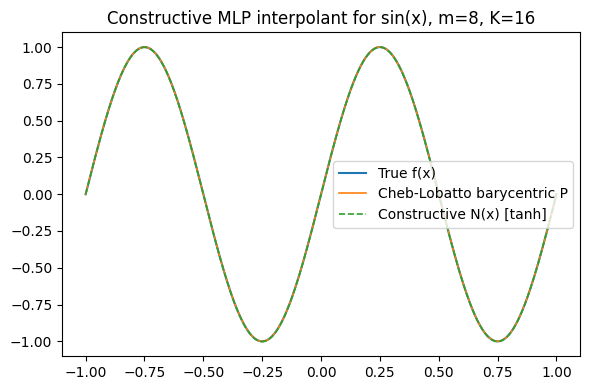

max_x |G_k - T_k| over k: [0.00000000e+00 8.43214387e-13 8.26250179e-12 1.48335477e-09
 6.22115670e-09 9.44834798e-07 1.62810427e-06 5.33713321e-04
 1.85760893e-04 3.61971892e-03 2.66555586e-02 1.69846864e-01
 1.24142183e+00 4.61240418e+00 6.12174218e+02 7.03808585e+01
 1.11022489e+04]
max over k: 11102.248923297506


In [54]:

# ============================
# Demo / diagnostic
# ============================

k_freq = 1
m = 8
K = 2 * m               # degree K interpolation (Theorem 2.3)
act = "tanh"             # <-- switch between "tanh" and "exp"
gamma = 1.0            # try 0.25..0.8

x_nodes = cheb_lobatto_nodes(K)                     # (K+1,)
f = lambda x: jnp.sin(2.0 * jnp.pi * DTYPE(k_freq) * x)
y_nodes = f(x_nodes)

# Barycentric evaluation (for checking the interpolant)
xs = jnp.linspace(-1.0, 1.0, 1001, dtype=DTYPE)
y_bary = barycentric_eval_lobatto(x_nodes, y_nodes, xs)

# Build network from the same nodal data
model = build_model_from_barycentric(y_nodes, K=K, act=act, gamma=gamma, h_mode = "auto", basis_mode="fornberg")

# Evaluate network
y_pred = model(xs)
y_true = f(xs)

print(f"max |barycentric P - f|: {float(jnp.max(jnp.abs(y_bary - y_true))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_bary - y_true) / jnp.linalg.norm(y_true)):.3e}")
print(f"max |network N - f|   : {float(jnp.max(jnp.abs(y_pred - y_true))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)):.3e}")
print(f"max |network - bary|  : {float(jnp.max(jnp.abs(y_pred - y_bary))):.3e}, "
        f"rel L2 err: {float(jnp.linalg.norm(y_pred - y_bary) / jnp.linalg.norm(y_bary)):.3e}")

# Chebyshev path consistency: G(x) ≈ T(x)
T = cheb_vandermonde(xs, K)             # (N,K+1)
y_poly = T @ model.V_raw                # direct Chebyshev polynomial
print("max |poly(T@V_raw) - bary|:", float(jnp.max(jnp.abs(y_poly - y_bary))))

# Plot
plt.figure(figsize=(6,4))
plt.plot(xs, y_true, label="True f(x)")
plt.plot(xs, y_bary, "-",  lw=1.2, label="Cheb-Lobatto barycentric P")
plt.plot(xs, y_pred, "--", lw=1.2, label=f"Constructive N(x) [{act}]")
plt.title(f"Constructive MLP interpolant for sin(x), m={m}, K={K}")
plt.legend(); plt.tight_layout(); plt.show()


# Micro-checks of the networkization alone (independent of V)
r_grid, W = fornberg_weights_centered(K)
p = jnp.arange(K + 1, dtype=DTYPE)
if act == "tanh":
    b0, t0 = analytic_bias_for_tanh("pi")
    deriv = tanh_derivatives_at_b_poly(K, t0)
    h = DTYPE(gamma / max(1, K // 2))
    Phi = jnp.tanh(xs[:, None] * (r_grid * h) + b0)
else:
    b0 = 0.0
    deriv = jnp.ones((K + 1,), dtype=DTYPE) * jnp.exp(DTYPE(b0))
    h = DTYPE(gamma / max(1, K // 2))
    Phi = jnp.exp(xs[:, None] * (r_grid * h) + b0)

denom = (h ** p) * deriv
S_rowscaled = W / denom[:, None]
C = cheb_monomial_coeffs(K)
G = Phi @ (C @ S_rowscaled).T
per_k = jnp.max(jnp.abs(G - cheb_vandermonde(xs, K)), axis=0)
print("max_x |G_k - T_k| over k:", np.array(per_k))
print("max over k:", float(per_k.max()))

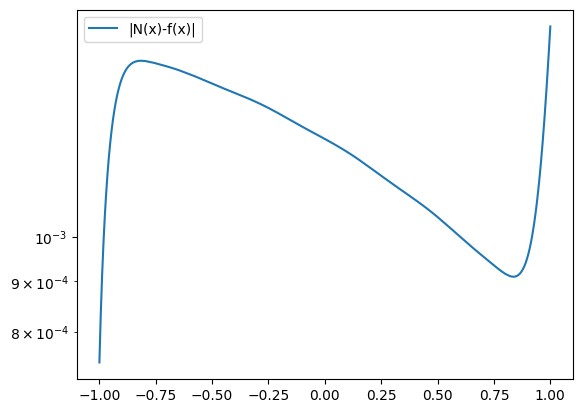

In [55]:
plt.semilogy(xs, np.abs(y_pred - y_true), label="|N(x)-f(x)|")
plt.legend()
plt.show()

In [56]:
model.r_grid.shape

(33,)


Monomial reproduction via current divided-difference map:
  p= 0: max|Ψ_p - x^0|=0.000e+00, relL2=0.000e+00
  p= 1: max|Ψ_p - x^1|=8.432e-13, relL2=2.423e-13
  p= 2: max|Ψ_p - x^2|=4.131e-12, relL2=1.296e-12
  p= 3: max|Ψ_p - x^3|=3.715e-10, relL2=1.626e-10
  p= 4: max|Ψ_p - x^4|=7.816e-10, relL2=3.268e-10
  p= 5: max|Ψ_p - x^5|=5.951e-08, relL2=3.245e-08
  p= 8: max|Ψ_p - x^8|=1.554e-06, relL2=1.247e-06
  p=12: max|Ψ_p - x^12|=7.395e-04, relL2=9.370e-04
  p=16: max|Ψ_p - x^16|=3.901e-02, relL2=2.959e-02
  worst over p≤K: max|·|=7.710e-02, worst relL2=6.527e-02


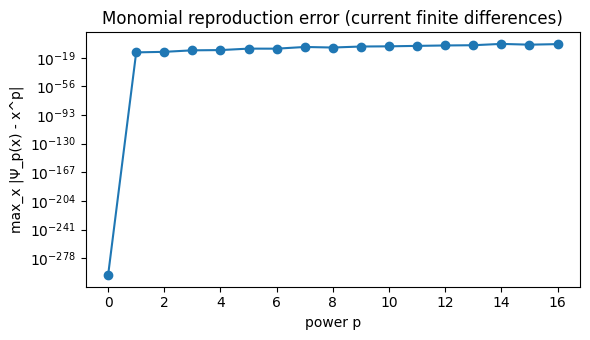

In [57]:
# ============================================================
# Monomial reproduction diagnostics for the current stencil
# ============================================================
def monomial_repro_diagnostics(model: ConstructivePhi1D,
                               xs: jnp.ndarray):
    """
    Uses the same (r_grid, W, h, b, act) as the model to build
    Psi_p(x) = (h^{-p} / phi^{(p)}(b)) * sum_i W[p,i] * phi(b + h r_i x)
    and compares it against x^p, for p=0..K.
    Returns (Psi, sup_errors, rel_l2_errors).
    """
    # same stencil used in the model
    r_grid, W = fornberg_weights_centered(model.K)          # (2K+1,), (K+1,2K+1)
    # derivatives at b for chosen activation
    deriv = phi_derivatives_at_b(model.K,
                                 act=model.act,
                                 b=model.b,
                                 t_cached=getattr(model, "t_cached", None))      # (K+1,)
    # build normalization 1/(h^p * phi^{(p)}(b))
    p = jnp.arange(model.K + 1, dtype=DTYPE)                # (K+1,)
    denom = (model.h ** p) * deriv                          # (K+1,)
    S_rowscaled = W / denom[:, None]                        # (K+1, 2K+1)

    # evaluate phi on the stencil
    Phi = model._phi(xs[:, None] * (r_grid * model.h) + model.b)  # (N, 2K+1)

    # Psi[:, p] ≈ x^p
    Psi = Phi @ S_rowscaled.T                               # (N, K+1)

    # true monomials on the same grid
    Xpow = jnp.stack([xs ** i for i in range(model.K + 1)], axis=1)  # (N, K+1)

    # errors per power p
    sup_err = jnp.max(jnp.abs(Psi - Xpow), axis=0)          # (K+1,)
    rel_l2  = (jnp.linalg.norm(Psi - Xpow, axis=0) /
               jnp.maximum(jnp.linalg.norm(Xpow, axis=0), DTYPE(1e-300)))

    # pretty print a few representative orders
    print("\nMonomial reproduction via current divided-difference map:")
    reps = [0, 1, 2, 3, 4, 5, 8, 12, 16, model.K]
    seen = set()
    for pp in reps:
        if 0 <= pp <= model.K and pp not in seen:
            seen.add(pp)
            print(f"  p={pp:>2}: max|Ψ_p - x^{pp}|={float(sup_err[pp]):.3e}, relL2={float(rel_l2[pp]):.3e}")
    print(f"  worst over p≤K: max|·|={float(jnp.max(sup_err)):.3e}, "
          f"worst relL2={float(jnp.max(rel_l2)):.3e}")

    return Psi, sup_err, rel_l2

# ---- run the diagnostic
Psi, sup_err, rel_l2 = monomial_repro_diagnostics(model, xs)

# Optional: visualize error vs p (log scale)
plt.figure(figsize=(6,3.5))
plt.semilogy(np.arange(model.K + 1), np.maximum(1e-300, np.array(sup_err)), marker='o', ls='-')
plt.xlabel("power p")
plt.ylabel("max_x |Ψ_p(x) - x^p|")
plt.title("Monomial reproduction error (current finite differences)")
plt.tight_layout()
plt.show()


In [58]:
# ---------- (A) condition-number proxy for the Ψ_p sums ----------
def monomial_condition_proxy(model: ConstructivePhi1D, xs: jnp.ndarray):
    r_grid, W = fornberg_weights_centered(model.K)
    p = jnp.arange(model.K + 1, dtype=DTYPE)
    deriv = phi_derivatives_at_b(model.K, act=model.act, b=model.b,
                                 t_cached=getattr(model, "t_cached", None))
    denom = (model.h ** p) * deriv                      # (K+1,)
    S_rowscaled = W / denom[:, None]                    # (K+1,2K+1)
    Phi = model._phi(xs[:, None] * (r_grid * model.h) + model.b)  # (N,2K+1)
    num = jnp.abs(Phi) @ jnp.abs(S_rowscaled.T)         # (N,K+1)
    den = jnp.abs(Phi @ S_rowscaled.T) + DTYPE(1e-300)  # (N,K+1)
    kappa = jnp.max(num / den, axis=0)                  # per p, larger = worse
    print("\nCondition proxy max_x κ_p:")
    for pp in [0,1,2,3,4,5,8,12,16,model.K]:
        if 0 <= pp <= model.K:
            print(f"  p={pp:>2}: κ≈ {float(kappa[pp]):.3e}")
    print(f"  worst over p≤K: κ≈ {float(jnp.max(kappa)):.3e}")
    return kappa  # (K+1,)

# ---------- (B) Mhaskar/“binomial” divided difference vs Fornberg ----------
def binomial_divdiff_phi_batch(act: Literal["tanh","exp"],
                               b: DTYPE,
                               p_vec: jnp.ndarray,   # (P,) integers
                               x_vec: jnp.ndarray,   # (X,)
                               h: DTYPE) -> jnp.ndarray:
    P = p_vec.astype(DTYPE)[:, None, None]             # (P,1,1)
    X = jnp.asarray(x_vec, dtype=DTYPE)[None, :, None] # (1,X,1)
    r = jnp.arange(jnp.max(p_vec)+1, dtype=DTYPE)[None,None,:]  # (1,1,Rmax)

    # mask r<=p for each p
    mask = (r <= P).astype(DTYPE)                      # (P,1,Rmax)
    # binom(p,r) with gammaln (broadcasting)
    binom_pr = jnp.exp(jax.scipy.special.gammaln(P+1.)
                       - jax.scipy.special.gammaln(r+1.)
                       - jax.scipy.special.gammaln(P-r+1.)) * mask
    coeff = ((-1.0) ** r) * binom_pr                   # (P,1,Rmax)

    w = (2.0 * r - P) * h * X                          # (P,X,Rmax)
    vals = jnp.tanh(b + w) if act == "tanh" else jnp.exp(b + w)
    s = jnp.sum(coeff * vals, axis=-1)                 # (P,X)

    # normalize by φ^{(p)}(b) and h^p
    if act == "tanh":
        deriv_all = tanh_derivatives_at_b_poly(int(jnp.max(p_vec)), jnp.tanh(b))
        deriv = deriv_all[p_vec]                       # (P,)
    else:
        deriv = jnp.ones_like(p_vec, dtype=DTYPE) * jnp.exp(b)
    norm = 1.0 / ((h ** p_vec.astype(DTYPE)) * deriv)  # (P,)
    return norm[:, None] * s                           # (P,X)

def compare_monomial_maps(model: ConstructivePhi1D, xs: jnp.ndarray):
    p_vec = jnp.arange(model.K + 1, dtype=jnp.int32)
    # Fornberg-based Ψ
    r_grid, W = fornberg_weights_centered(model.K)
    deriv = phi_derivatives_at_b(model.K, act=model.act, b=model.b,
                                 t_cached=getattr(model, "t_cached", None))
    denom = (model.h ** jnp.arange(model.K+1, dtype=DTYPE)) * deriv
    S_rowscaled = W / denom[:, None]
    Phi = model._phi(xs[:, None] * (r_grid * model.h) + model.b)
    Psi_fornberg = (Phi @ S_rowscaled.T).T                      # (K+1,N)

    # Binomial-based Ψ
    Psi_binom = binomial_divdiff_phi_batch(model.act, model.b, p_vec, xs, model.h)  # (K+1,N)

    # errors to true monomials
    Xpow = jnp.stack([xs ** i for i in range(model.K + 1)], axis=0)  # (K+1,N)
    err_f = jnp.max(jnp.abs(Psi_fornberg - Xpow), axis=1)
    err_b = jnp.max(jnp.abs(Psi_binom   - Xpow), axis=1)
    print("\nmax_x |Ψ_p - x^p|   (Fornberg vs Binomial) for a few p:")
    for pp in [0,1,2,3,4,5,8,12,16,model.K]:
        if 0 <= pp <= model.K:
            print(f"  p={pp:>2}: {float(err_f[pp]):.3e}  |  {float(err_b[pp]):.3e}")
    return err_f, err_b

In [59]:
kappa = monomial_condition_proxy(model, xs)


Condition proxy max_x κ_p:
  p= 0: κ≈ 1.000e+00
  p= 1: κ≈ 4.555e+15
  p= 2: κ≈ 1.766e+15
  p= 3: κ≈ 2.408e+15
  p= 4: κ≈ 5.945e+15
  p= 5: κ≈ 8.637e+16
  p= 8: κ≈ 2.300e+15
  p=12: κ≈ 1.980e+15
  p=16: κ≈ 7.673e+16
  p=16: κ≈ 7.673e+16
  worst over p≤K: κ≈ 8.637e+16


In [60]:
err_f, err_b = compare_monomial_maps(model, xs)


max_x |Ψ_p - x^p|   (Fornberg vs Binomial) for a few p:
  p= 0: 0.000e+00  |  0.000e+00
  p= 1: 8.432e-13  |  2.993e+00
  p= 2: 4.131e-12  |  2.863e+00
  p= 3: 3.715e-10  |  8.770e+00
  p= 4: 7.816e-10  |  1.297e+01
  p= 5: 5.951e-08  |  3.345e+01
  p= 8: 1.554e-06  |  1.449e+02
  p=12: 7.395e-04  |  1.527e+03
  p=16: 3.901e-02  |  3.980e+03
  p=16: 3.901e-02  |  3.980e+03


In [61]:
# monomial_fit_1hl.py
# Single-hidden-layer MLP with either tanh or SiLU features, fitted by FP64 SVD
# to approximate x^k on [-1, 1] to near machine precision.

import os
os.environ["JAX_ENABLE_X64"] = "1"

import math
from typing import Callable, Tuple

import jax
import jax.numpy as jnp
import jax.nn as jnn
from flax import nnx


# --------------------------
# Utilities / feature design
# --------------------------
def chebyshev_lobatto_nodes(n: int) -> jnp.ndarray:
    """x_i = cos(pi*i/(n-1)), i=0..n-1 on [-1,1]. Good for LS conditioning."""
    i = jnp.arange(n)
    return jnp.cos(math.pi * i / (n - 1))


def make_basis(width: int, slope: float) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Fixed 'ridge' features: phi_j(x) = act(slope*(x - c_j))
    Centers c_j spaced on [-1,1]; slopes all identical to avoid saturation/flatness.
    """
    c = jnp.linspace(-1.0, 1.0, width)
    a = jnp.full((width,), slope)
    return a, c


def apply_activation(z: jnp.ndarray, activation: str) -> jnp.ndarray:
    """Activation dispatcher for features."""
    if activation == "tanh":
        return jnp.tanh(z)
    if activation in ("silu", "swish"):
        return jnn.silu(z)  # z * sigmoid(z)
    raise ValueError(f"Unknown activation: {activation}")


def design_matrix(
    x: jnp.ndarray,
    a: jnp.ndarray,
    c: jnp.ndarray,
    activation: str,
    add_bias: bool = True,
) -> jnp.ndarray:
    """Phi[i,j] = act(a_j*(x_i - c_j)); optionally append a constant column."""
    X = x[:, None]        # (N,1)
    A = a[None, :]        # (1,W)
    C = c[None, :]        # (1,W)
    Phi = apply_activation(A * (X - C), activation)  # (N,W)
    if add_bias:
        Phi = jnp.concatenate([Phi, jnp.ones((Phi.shape[0], 1))], axis=1)
    return Phi


def fit_output_weights(Phi: jnp.ndarray, y: jnp.ndarray, rcond: float = 1e-18) -> jnp.ndarray:
    """
    Solve min ||Phi @ w - y||_2 using SVD-based lstsq in FP64.
    Returns w of shape (W [+ bias],).
    """
    w, *_ = jnp.linalg.lstsq(Phi, y, rcond=rcond)
    return w


# --------------------------
# NNX module (forward only)
# --------------------------
class SingleHiddenAct(nnx.Module):
    """
    Single-hidden-layer model with fixed feature parameters (a, c) and
    trainable/readable output weights w. Activation is 'tanh' or 'silu'.
    """
    def __init__(self, width: int, activation: str, *, key: jax.Array):
        self.width = width
        self.activation = activation
        self.a = nnx.Param(jnp.ones((width,)))           # slopes
        self.c = nnx.Param(jnp.zeros((width,)))          # centers
        self.w = nnx.Param(jnp.zeros((width + 1,)))      # output weights + bias

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        X = jnp.atleast_1d(x)
        A = self.a[None, :]    # (1,W)
        C = self.c[None, :]    # (1,W)
        Phi = apply_activation(A * (X[:, None] - C), self.activation)  # (N,W)
        Phi = jnp.concatenate([Phi, jnp.ones((Phi.shape[0], 1))], axis=1)
        y = Phi @ self.w
        return y if x.ndim > 0 else y[0]


# --------------------------
# Fit + evaluate
# --------------------------
def build_and_fit(
    k: int,
    width: int,
    activation: str = "tanh",   # or "silu"
    n_train: int = 600,
    slope: float = 3.5,         # good default for tanh; try 4.0–5.0 for SiLU
    rcond: float = 1e-18,
) -> Tuple[SingleHiddenAct, float, float]:
    """
    Fit x^k on [-1,1] via fixed features + SVD for output layer.
    Returns (model, max_abs_err, rel_L2_err) on a dense test grid.
    """
    # 1) training data on Chebyshev-Lobatto nodes
    x_tr = chebyshev_lobatto_nodes(n_train)
    y_tr = x_tr ** k

    # 2) design basis
    a, c = make_basis(width, slope)
    Phi = design_matrix(x_tr, a, c, activation, add_bias=True)

    # 3) stable least-squares fit
    w = fit_output_weights(Phi, y_tr, rcond=rcond)

    # 4) package into NNX module
    key = jax.random.PRNGKey(0)
    model = SingleHiddenAct(width, activation, key=key)
    model.a = nnx.Param(a)
    model.c = nnx.Param(c)
    model.w = nnx.Param(w)

    # 5) evaluate on dense uniform grid
    x_te = jnp.linspace(-1.0, 1.0, 2001)
    y_true = x_te ** k
    y_pred = model(x_te)
    abs_err = jnp.abs(y_pred - y_true)
    max_abs = float(abs_err.max())
    # safe when k=0:
    rel_L2 = float(jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true + 1e-300))

    return model, max_abs, rel_L2


# --------------------------
# Demo
# --------------------------
if __name__ == "__main__":
    # Try a sweep of k with both activations.
    ks = [0, 1, 2, 5, 8, 12, 16]
    for activation in ["tanh", "silu"]:
        print(f"\n=== Activation: {activation} ===")
        for k in ks:
            # Heuristic: width grows slowly with k; tune slope per activation.
            width = max(24, 8 * k)
            slope = 3.5 if activation == "tanh" else 6.5
            model, emax, e_rel = build_and_fit(
                k=k, width=width, activation=activation, n_train=600, slope=slope
            )
            print(f"k={k:2d} | width={width:3d} | slope={slope:3.1f} | "
                  f"max|err|≈{emax:.3e} | relL2≈{e_rel:.3e}")



=== Activation: tanh ===
k= 0 | width= 24 | slope=3.5 | max|err|≈1.232e-14 | relL2≈7.997e-15
k= 1 | width= 24 | slope=3.5 | max|err|≈1.229e-05 | relL2≈9.934e-06
k= 2 | width= 24 | slope=3.5 | max|err|≈3.072e-05 | relL2≈3.190e-05
k= 5 | width= 40 | slope=3.5 | max|err|≈1.836e-06 | relL2≈2.745e-06
k= 8 | width= 64 | slope=3.5 | max|err|≈8.988e-08 | relL2≈1.236e-07
k=12 | width= 96 | slope=3.5 | max|err|≈1.606e-07 | relL2≈2.904e-07
k=16 | width=128 | slope=3.5 | max|err|≈5.963e-07 | relL2≈1.323e-06

=== Activation: silu ===
k= 0 | width= 24 | slope=6.5 | max|err|≈1.754e-14 | relL2≈9.704e-15
k= 1 | width= 24 | slope=6.5 | max|err|≈6.856e-05 | relL2≈3.985e-05
k= 2 | width= 24 | slope=6.5 | max|err|≈1.567e-04 | relL2≈1.168e-04
k= 5 | width= 40 | slope=6.5 | max|err|≈5.926e-06 | relL2≈6.353e-06
k= 8 | width= 64 | slope=6.5 | max|err|≈3.841e-07 | relL2≈4.384e-07
k=12 | width= 96 | slope=6.5 | max|err|≈4.478e-07 | relL2≈8.682e-07
k=16 | width=128 | slope=6.5 | max|err|≈1.124e-06 | relL2≈2.303e